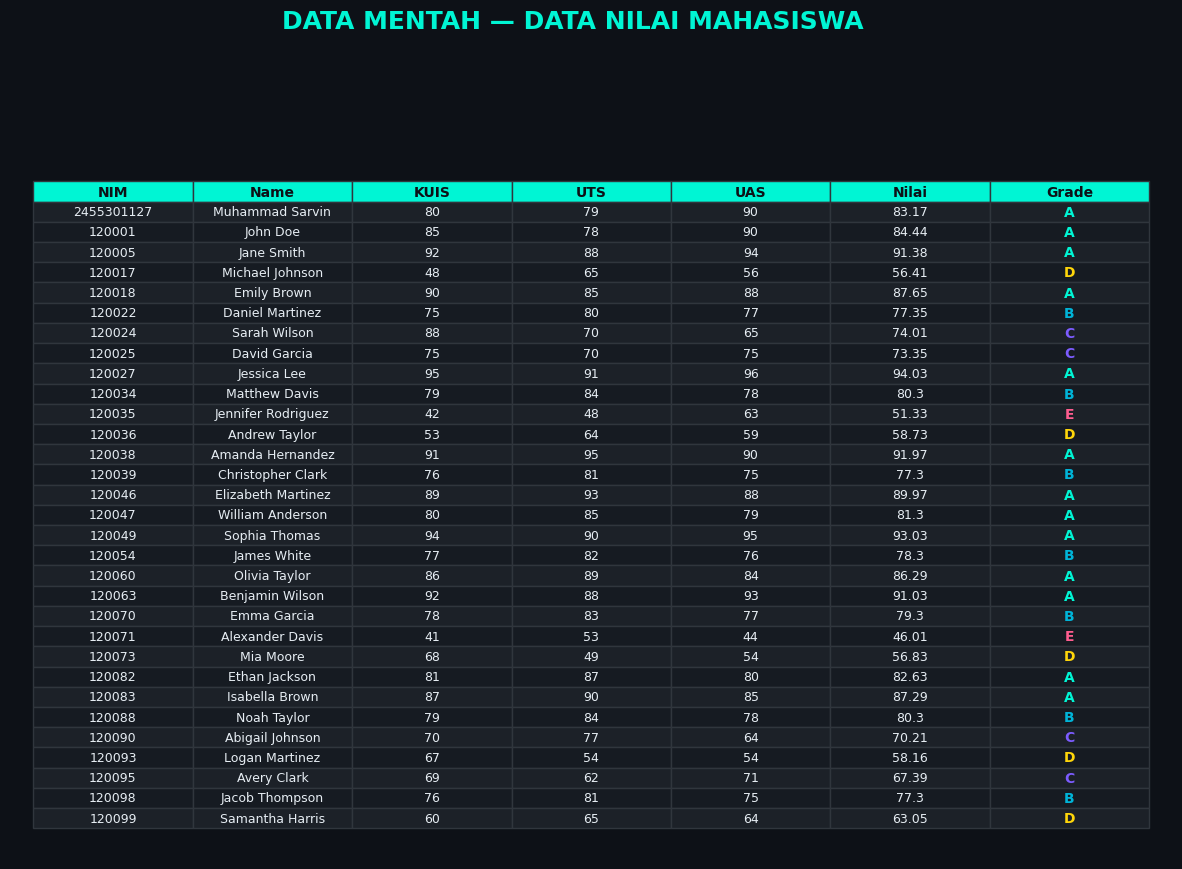

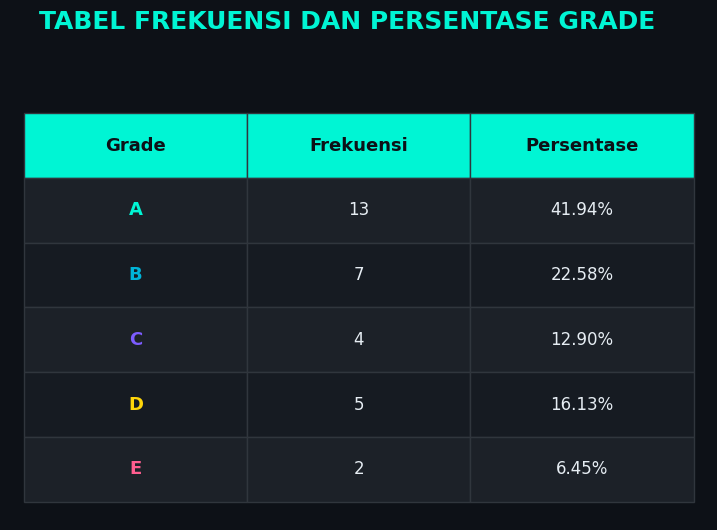

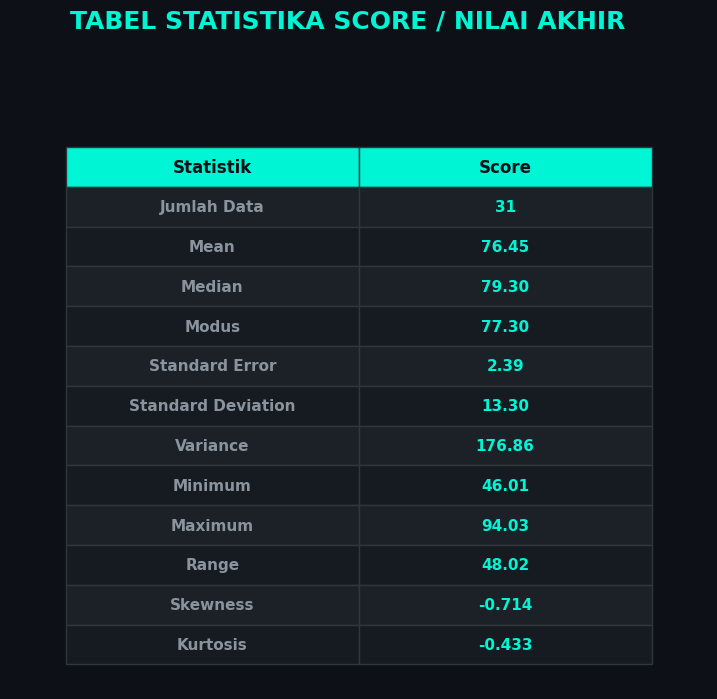

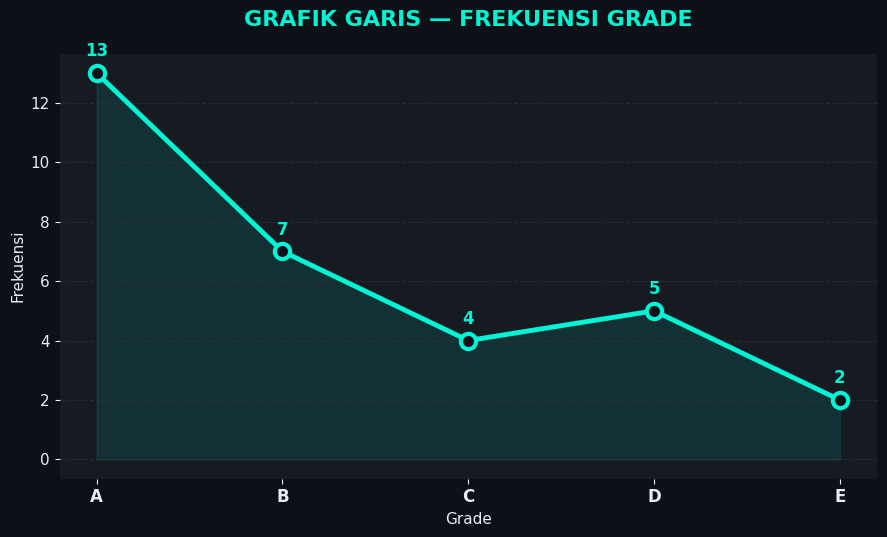

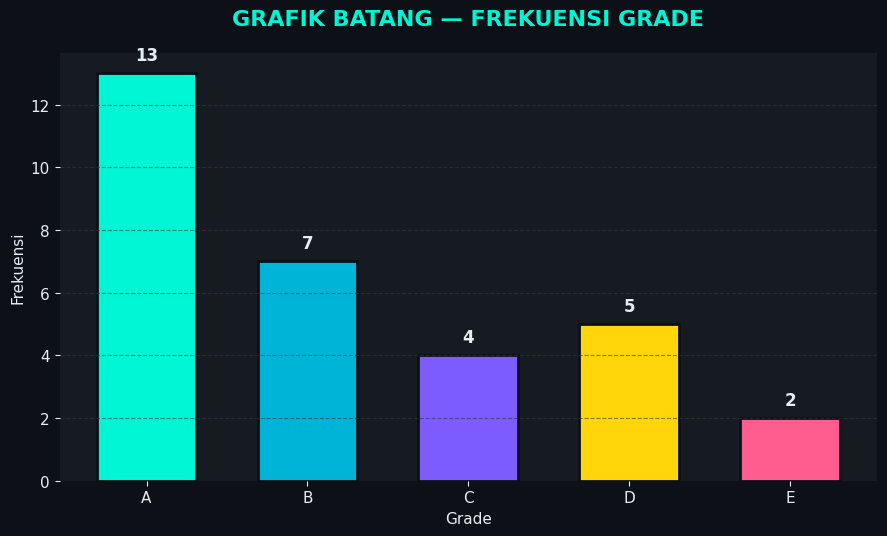

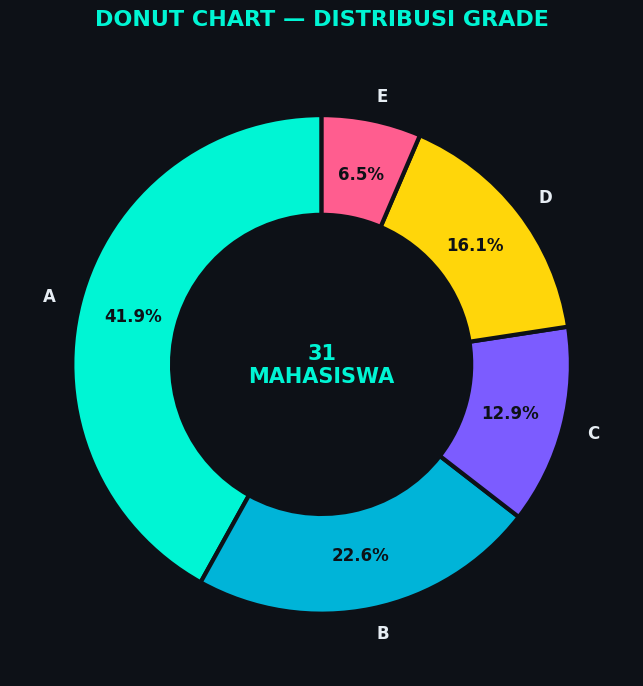

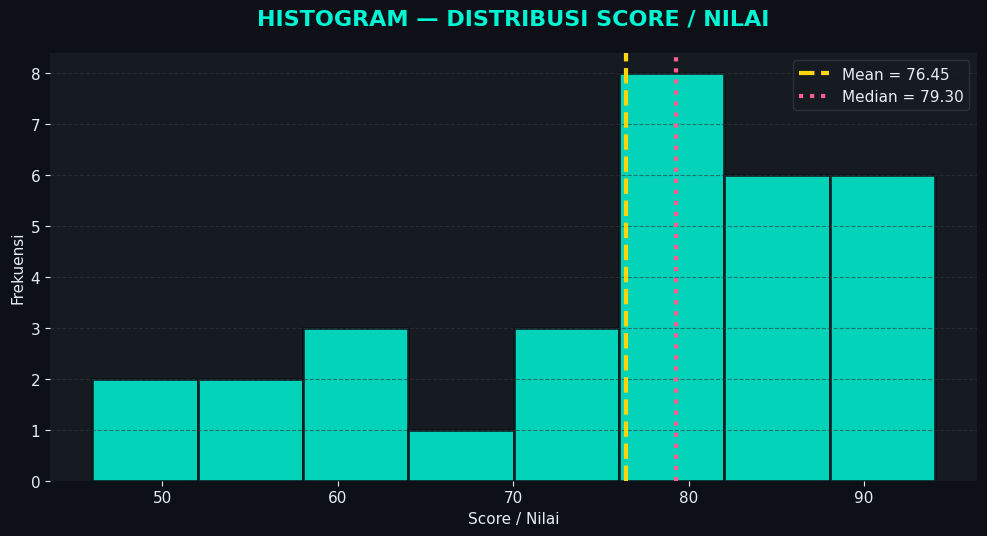

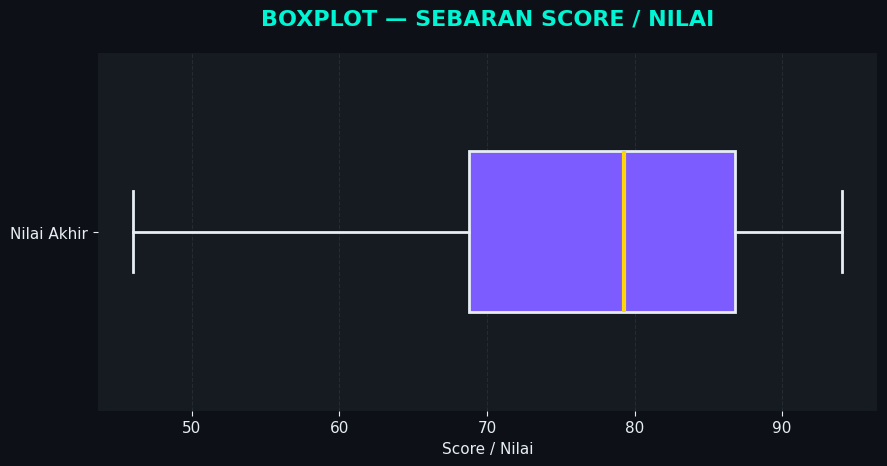

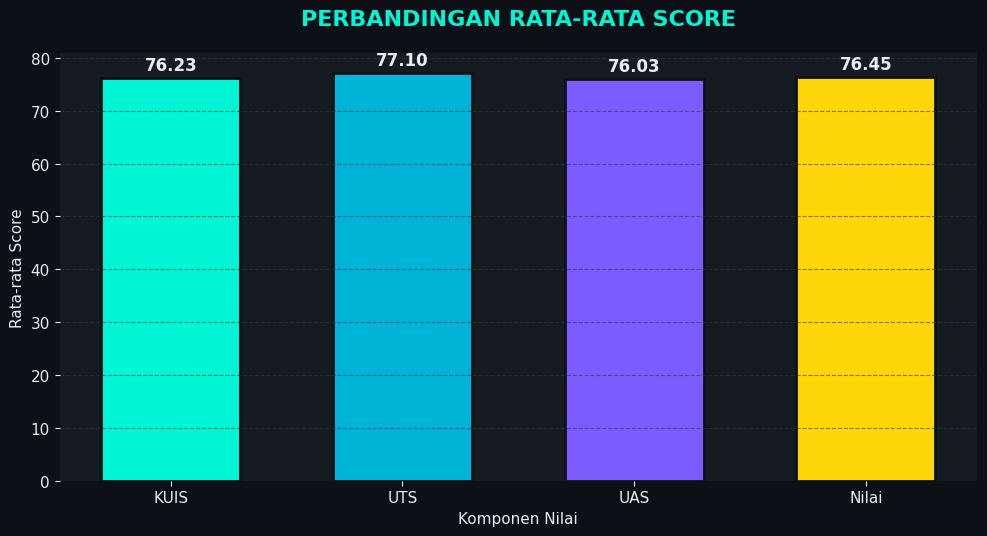

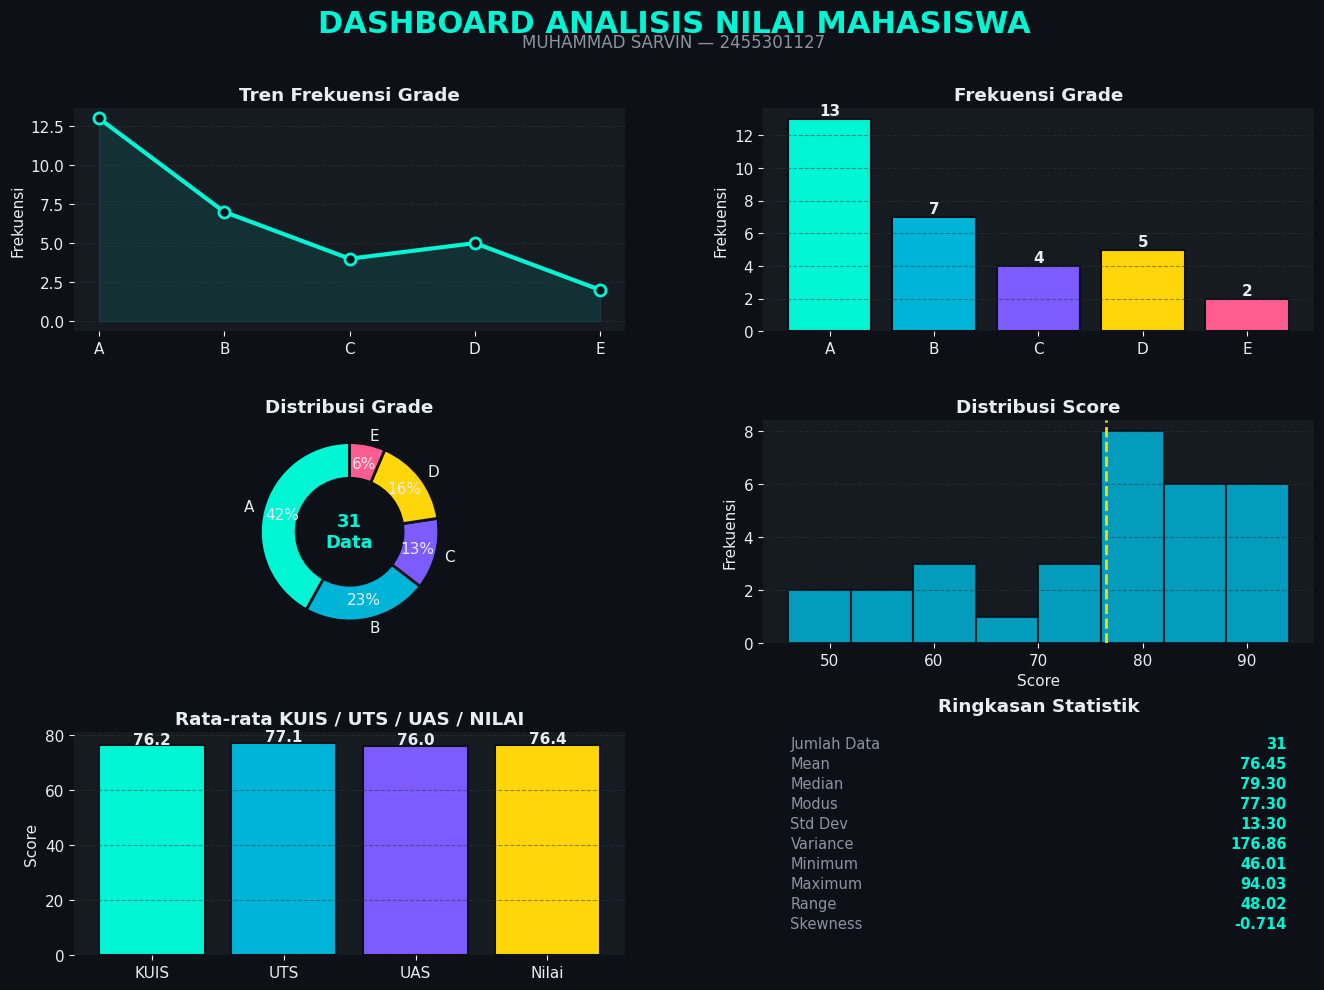

In [14]:
# %% ========================================================
# A. IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# %% ========================================================
# B. MEMBACA DATA
# =========================================================

path = "sarvin.xlsx"

dataraw = pd.read_excel(path)

kolom_nilai = [
    "KUIS",
    "UTS",
    "UAS",
    "Nilai"
]

for kolom in kolom_nilai:
    if kolom in dataraw.columns:
        dataraw[kolom] = pd.to_numeric(
            dataraw[kolom],
            errors="coerce"
        )


# %% ========================================================
# C. TEMA IT STYLE
# =========================================================

plt.style.use("dark_background")

BG = "#0D1117"
CARD = "#161B22"
CARD2 = "#1C2128"
GRID = "#30363D"

ACCENT = "#00F5D4"
CYAN = "#00B4D8"
PURPLE = "#7C5CFF"
YELLOW = "#FFD60A"
PINK = "#FF5D8F"

TEXT = "#E6EDF3"
SUBTEXT = "#8B949E"

NEON = [
    ACCENT,
    CYAN,
    PURPLE,
    YELLOW,
    PINK
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": CARD,
    "savefig.facecolor": BG,
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "axes.edgecolor": GRID,
    "font.family": "DejaVu Sans",
    "font.size": 11
})


# %% ========================================================
# D. FUNGSI MEMBUAT TABEL
# =========================================================

def buat_tabel(
    data,
    judul,
    nama_file,
    figsize=(14, 10),
    font_size=9
):

    fig, ax = plt.subplots(
        figsize=figsize
    )

    fig.patch.set_facecolor(BG)

    ax.set_facecolor(CARD)

    ax.axis("off")

    # --------------------------------------------------------
    # JUDUL DI LUAR AREA TABEL
    # --------------------------------------------------------

    fig.suptitle(
        judul,
        fontsize=18,
        fontweight="bold",
        color=ACCENT,
        y=0.96
    )

    # --------------------------------------------------------
    # TABEL
    # --------------------------------------------------------

    table = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        bbox=[
            0.02,
            0.04,
            0.96,
            0.84
        ]
    )

    table.auto_set_font_size(False)

    table.set_fontsize(font_size)

    # --------------------------------------------------------
    # STYLE TABEL
    # --------------------------------------------------------

    for (row, col), cell in table.get_celld().items():

        cell.set_edgecolor(GRID)

        cell.set_linewidth(1)

        # HEADER
        if row == 0:

            cell.set_facecolor(
                ACCENT
            )

            cell.set_text_props(
                color=BG,
                weight="bold",
                fontsize=font_size + 1
            )

        # DATA
        else:

            if row % 2 == 0:

                cell.set_facecolor(
                    CARD
                )

            else:

                cell.set_facecolor(
                    CARD2
                )

            cell.set_text_props(
                color=TEXT,
                fontsize=font_size
            )

    # --------------------------------------------------------
    # WARNA GRADE
    # --------------------------------------------------------

    if "Grade" in data.columns:

        kolom_grade = list(
            data.columns
        ).index("Grade")

        warna_grade = {
            "A": ACCENT,
            "B": CYAN,
            "C": PURPLE,
            "D": YELLOW,
            "E": PINK
        }

        for row in range(
            1,
            len(data) + 1
        ):

            grade = str(
                data.iloc[
                    row - 1,
                    kolom_grade
                ]
            )

            if grade in warna_grade:

                table[
                    (row, kolom_grade)
                ].set_text_props(
                    color=warna_grade[grade],
                    weight="bold",
                    fontsize=font_size + 1
                )

    # --------------------------------------------------------
    # SIMPAN
    # --------------------------------------------------------

    plt.savefig(
        nama_file,
        dpi=300,
        bbox_inches="tight",
        facecolor=BG
    )

    plt.show()

    plt.close()


# %% ========================================================
# E. TABEL DATA MENTAH
# =========================================================

tabel_data_mentah = dataraw.copy()

buat_tabel(
    tabel_data_mentah,
    "DATA MENTAH — DATA NILAI MAHASISWA",
    "01_data_mentah.png",
    figsize=(15, 10),
    font_size=9
)


# %% ========================================================
# F. TABEL FREKUENSI GRADE
# =========================================================

urutan_grade = [
    "A",
    "B",
    "C",
    "D",
    "E"
]

frekuensi = (
    dataraw["Grade"]
    .value_counts()
    .reindex(
        urutan_grade,
        fill_value=0
    )
)

total_data = frekuensi.sum()

persentase = (
    frekuensi /
    total_data *
    100
)

tabel_frekuensi = pd.DataFrame({

    "Grade":
        urutan_grade,

    "Frekuensi":
        frekuensi.values,

    "Persentase":
        [
            f"{x:.2f}%"
            for x in persentase.values
        ]
})


# %% ========================================================
# G. TAMPILKAN TABEL FREKUENSI
# =========================================================

buat_tabel(
    tabel_frekuensi,
    "TABEL FREKUENSI DAN PERSENTASE GRADE",
    "02_frekuensi_grade.png",
    figsize=(9, 6),
    font_size=12
)


# %% ========================================================
# H. STATISTIKA SCORE / NILAI
# =========================================================

nilai = (
    dataraw["Nilai"]
    .dropna()
)

mean_nilai = nilai.mean()

median_nilai = nilai.median()

modus_nilai = nilai.mode().iloc[0]

std_nilai = nilai.std()

sem_nilai = nilai.sem()

variance_nilai = nilai.var()

minimum_nilai = nilai.min()

maximum_nilai = nilai.max()

range_nilai = (
    maximum_nilai -
    minimum_nilai
)

skewness_nilai = nilai.skew()

kurtosis_nilai = nilai.kurtosis()


# %% ========================================================
# I. TABEL STATISTIKA SCORE
# =========================================================

tabel_score = pd.DataFrame({

    "Statistik": [

        "Jumlah Data",

        "Mean",

        "Median",

        "Modus",

        "Standard Error",

        "Standard Deviation",

        "Variance",

        "Minimum",

        "Maximum",

        "Range",

        "Skewness",

        "Kurtosis"

    ],

    "Score": [

        f"{len(nilai)}",

        f"{mean_nilai:.2f}",

        f"{median_nilai:.2f}",

        f"{modus_nilai:.2f}",

        f"{sem_nilai:.2f}",

        f"{std_nilai:.2f}",

        f"{variance_nilai:.2f}",

        f"{minimum_nilai:.2f}",

        f"{maximum_nilai:.2f}",

        f"{range_nilai:.2f}",

        f"{skewness_nilai:.3f}",

        f"{kurtosis_nilai:.3f}"

    ]

})


# %% ========================================================
# J. TAMPILKAN TABEL SCORE
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 8)
)

fig.patch.set_facecolor(BG)

ax.set_facecolor(CARD)

ax.axis("off")

fig.suptitle(
    "TABEL STATISTIKA SCORE / NILAI AKHIR",
    fontsize=18,
    fontweight="bold",
    color=ACCENT,
    y=0.96
)

table = ax.table(
    cellText=tabel_score.values,
    colLabels=tabel_score.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    bbox=[
        0.08,
        0.04,
        0.84,
        0.84
    ]
)

table.auto_set_font_size(False)

table.set_fontsize(11)

for (row, col), cell in table.get_celld().items():

    cell.set_edgecolor(GRID)

    cell.set_linewidth(1)

    if row == 0:

        cell.set_facecolor(
            ACCENT
        )

        cell.set_text_props(
            color=BG,
            weight="bold",
            fontsize=12
        )

    else:

        if row % 2 == 0:

            cell.set_facecolor(
                CARD
            )

        else:

            cell.set_facecolor(
                CARD2
            )

        if col == 0:

            cell.set_text_props(
                color=SUBTEXT,
                weight="bold"
            )

        else:

            cell.set_text_props(
                color=ACCENT,
                weight="bold"
            )

plt.savefig(
    "03_tabel_score.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

plt.close()


# %% ========================================================
# K. GRAFIK GARIS FREKUENSI GRADE
# =========================================================

x = np.arange(
    len(urutan_grade)
)

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.plot(
    x,
    frekuensi.values,
    color=ACCENT,
    linewidth=3.5,
    marker="o",
    markersize=11,
    markerfacecolor=BG,
    markeredgecolor=ACCENT,
    markeredgewidth=3
)

ax.fill_between(
    x,
    frekuensi.values,
    color=ACCENT,
    alpha=0.10
)

for i, value in enumerate(
    frekuensi.values
):

    ax.annotate(
        str(value),
        (
            i,
            value
        ),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=12,
        fontweight="bold",
        color=ACCENT
    )

ax.set_xticks(x)

ax.set_xticklabels(
    urutan_grade,
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Grade"
)

ax.set_ylabel(
    "Frekuensi"
)

ax.set_title(
    "GRAFIK GARIS — FREKUENSI GRADE",
    fontsize=16,
    fontweight="bold",
    color=ACCENT,
    pad=20
)

ax.grid(
    axis="y",
    color=GRID,
    linestyle="--",
    alpha=0.6
)

for spine in ax.spines.values():

    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    "04_grafik_garis_grade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# %% ========================================================
# L. GRAFIK BATANG FREKUENSI GRADE
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

bars = ax.bar(
    urutan_grade,
    frekuensi.values,
    color=NEON,
    edgecolor=BG,
    linewidth=2,
    width=0.62
)

for bar in bars:

    tinggi = bar.get_height()

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        tinggi + 0.3,

        str(int(tinggi)),

        ha="center",

        va="bottom",

        fontsize=12,

        fontweight="bold",

        color=TEXT
    )

ax.set_title(
    "GRAFIK BATANG — FREKUENSI GRADE",
    fontsize=16,
    fontweight="bold",
    color=ACCENT,
    pad=20
)

ax.set_xlabel(
    "Grade"
)

ax.set_ylabel(
    "Frekuensi"
)

ax.grid(
    axis="y",
    color=GRID,
    linestyle="--",
    alpha=0.6
)

for spine in ax.spines.values():

    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    "05_grafik_batang_grade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# %% ========================================================
# M. DONUT CHART GRADE
# =========================================================

fig, ax = plt.subplots(
    figsize=(7, 7)
)

wedges, texts, autotexts = ax.pie(

    frekuensi.values,

    labels=urutan_grade,

    autopct="%1.1f%%",

    colors=NEON,

    startangle=90,

    pctdistance=0.78,

    wedgeprops={
        "width": 0.40,
        "edgecolor": BG,
        "linewidth": 3
    },

    textprops={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

for text in texts:

    text.set_color(
        TEXT
    )

for text in autotexts:

    text.set_color(
        BG
    )

    text.set_fontweight(
        "bold"
    )

ax.text(
    0,
    0,
    f"{total_data}\nMAHASISWA",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color=ACCENT
)

ax.set_title(
    "DONUT CHART — DISTRIBUSI GRADE",
    fontsize=16,
    fontweight="bold",
    color=ACCENT,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "06_donut_grade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# %% ========================================================
# N. HISTOGRAM SCORE
# =========================================================

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

ax.hist(
    nilai,
    bins=8,
    color=ACCENT,
    edgecolor=BG,
    linewidth=2,
    alpha=0.85
)

ax.axvline(
    mean_nilai,
    color=YELLOW,
    linewidth=3,
    linestyle="--",
    label=f"Mean = {mean_nilai:.2f}"
)

ax.axvline(
    median_nilai,
    color=PINK,
    linewidth=3,
    linestyle=":",
    label=f"Median = {median_nilai:.2f}"
)

ax.set_title(
    "HISTOGRAM — DISTRIBUSI SCORE / NILAI",
    fontsize=16,
    fontweight="bold",
    color=ACCENT,
    pad=20
)

ax.set_xlabel(
    "Score / Nilai"
)

ax.set_ylabel(
    "Frekuensi"
)

ax.grid(
    axis="y",
    color=GRID,
    linestyle="--",
    alpha=0.6
)

ax.legend(
    facecolor=CARD,
    edgecolor=GRID
)

for spine in ax.spines.values():

    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    "07_histogram_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# %% ========================================================
# O. BOXPLOT SCORE
# =========================================================

fig, ax = plt.subplots(
    figsize=(9, 4.8)
)

ax.boxplot(

    nilai,

    vert=False,

    patch_artist=True,

    widths=0.45,

    boxprops={
        "facecolor": PURPLE,
        "edgecolor": TEXT,
        "linewidth": 2
    },

    medianprops={
        "color": YELLOW,
        "linewidth": 3
    },

    whiskerprops={
        "color": TEXT,
        "linewidth": 2
    },

    capprops={
        "color": TEXT,
        "linewidth": 2
    },

    flierprops={
        "marker": "o",
        "markerfacecolor": PINK,
        "markeredgecolor": PINK,
        "markersize": 7
    }
)

ax.set_title(
    "BOXPLOT — SEBARAN SCORE / NILAI",
    fontsize=16,
    fontweight="bold",
    color=ACCENT,
    pad=20
)

ax.set_xlabel(
    "Score / Nilai"
)

ax.set_yticks(
    [1]
)

ax.set_yticklabels(
    ["Nilai Akhir"]
)

ax.grid(
    axis="x",
    color=GRID,
    linestyle="--",
    alpha=0.6
)

for spine in ax.spines.values():

    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    "08_boxplot_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# %% ========================================================
# P. RATA-RATA KUIS UTS UAS NILAI
# =========================================================

kolom_tersedia = [
    kolom
    for kolom in [
        "KUIS",
        "UTS",
        "UAS",
        "Nilai"
    ]
    if kolom in dataraw.columns
]

rata_rata = [
    dataraw[kolom].mean()
    for kolom in kolom_tersedia
]


# %% ========================================================
# Q. GRAFIK PERBANDINGAN SCORE
# =========================================================

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

warna = NEON[
    :len(kolom_tersedia)
]

bars = ax.bar(
    kolom_tersedia,
    rata_rata,
    color=warna,
    width=0.6,
    edgecolor=BG,
    linewidth=2
)

for bar, rata in zip(
    bars,
    rata_rata
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() + 0.7,

        f"{rata:.2f}",

        ha="center",

        va="bottom",

        fontsize=12,

        fontweight="bold",

        color=TEXT
    )

ax.set_title(
    "PERBANDINGAN RATA-RATA SCORE",
    fontsize=16,
    fontweight="bold",
    color=ACCENT,
    pad=20
)

ax.set_xlabel(
    "Komponen Nilai"
)

ax.set_ylabel(
    "Rata-rata Score"
)

ax.grid(
    axis="y",
    color=GRID,
    linestyle="--",
    alpha=0.6
)

for spine in ax.spines.values():

    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    "09_perbandingan_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# %% ========================================================
# R. DASHBOARD ANALISIS
# =========================================================

fig = plt.figure(
    figsize=(16, 11)
)

fig.patch.set_facecolor(
    BG
)

fig.suptitle(
    "DASHBOARD ANALISIS NILAI MAHASISWA",
    fontsize=22,
    fontweight="bold",
    color=ACCENT,
    y=0.97
)

fig.text(
    0.5,
    0.935,
    "MUHAMMAD SARVIN — 2455301127",
    ha="center",
    fontsize=12,
    color=SUBTEXT
)

gs = fig.add_gridspec(
    3,
    2,
    hspace=0.40,
    wspace=0.25
)


# %% ---------------------------------------------------------
# DASHBOARD 1 — GRAFIK GARIS
# ----------------------------------------------------------

ax1 = fig.add_subplot(
    gs[0, 0]
)

ax1.plot(
    x,
    frekuensi.values,
    color=ACCENT,
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor=BG,
    markeredgecolor=ACCENT,
    markeredgewidth=2
)

ax1.fill_between(
    x,
    frekuensi.values,
    color=ACCENT,
    alpha=0.10
)

ax1.set_xticks(
    x
)

ax1.set_xticklabels(
    urutan_grade
)

ax1.set_title(
    "Tren Frekuensi Grade",
    fontweight="bold"
)

ax1.set_ylabel(
    "Frekuensi"
)

ax1.grid(
    axis="y",
    color=GRID,
    linestyle="--",
    alpha=0.5
)

for spine in ax1.spines.values():

    spine.set_visible(False)


# %% ---------------------------------------------------------
# DASHBOARD 2 — GRAFIK BATANG
# ----------------------------------------------------------

ax2 = fig.add_subplot(
    gs[0, 1]
)

bars = ax2.bar(
    urutan_grade,
    frekuensi.values,
    color=NEON,
    edgecolor=BG,
    linewidth=1.5
)

for bar in bars:

    ax2.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() + 0.2,

        str(
            int(
                bar.get_height()
            )
        ),

        ha="center",

        fontweight="bold"
    )

ax2.set_title(
    "Frekuensi Grade",
    fontweight="bold"
)

ax2.set_ylabel(
    "Frekuensi"
)

ax2.grid(
    axis="y",
    color=GRID,
    linestyle="--",
    alpha=0.5
)

for spine in ax2.spines.values():

    spine.set_visible(False)


# %% ---------------------------------------------------------
# DASHBOARD 3 — DONUT
# ----------------------------------------------------------

ax3 = fig.add_subplot(
    gs[1, 0]
)

ax3.pie(

    frekuensi.values,

    labels=urutan_grade,

    autopct="%1.0f%%",

    colors=NEON,

    startangle=90,

    pctdistance=0.78,

    wedgeprops={
        "width": 0.40,
        "edgecolor": BG,
        "linewidth": 2
    }
)

ax3.text(
    0,
    0,
    f"{total_data}\nData",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color=ACCENT
)

ax3.set_title(
    "Distribusi Grade",
    fontweight="bold"
)


# %% ---------------------------------------------------------
# DASHBOARD 4 — HISTOGRAM
# ----------------------------------------------------------

ax4 = fig.add_subplot(
    gs[1, 1]
)

ax4.hist(
    nilai,
    bins=8,
    color=CYAN,
    edgecolor=BG,
    linewidth=1.5,
    alpha=0.85
)

ax4.axvline(
    mean_nilai,
    color=YELLOW,
    linestyle="--",
    linewidth=2
)

ax4.set_title(
    "Distribusi Score",
    fontweight="bold"
)

ax4.set_xlabel(
    "Score"
)

ax4.set_ylabel(
    "Frekuensi"
)

ax4.grid(
    axis="y",
    color=GRID,
    linestyle="--",
    alpha=0.5
)

for spine in ax4.spines.values():

    spine.set_visible(False)


# %% ---------------------------------------------------------
# DASHBOARD 5 — PERBANDINGAN SCORE
# ----------------------------------------------------------

ax5 = fig.add_subplot(
    gs[2, 0]
)

bars = ax5.bar(
    kolom_tersedia,
    rata_rata,
    color=NEON[
        :len(kolom_tersedia)
    ],
    edgecolor=BG,
    linewidth=1.5
)

for bar, rata in zip(
    bars,
    rata_rata
):

    ax5.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() + 0.5,

        f"{rata:.1f}",

        ha="center",

        fontweight="bold"
    )

ax5.set_title(
    "Rata-rata KUIS / UTS / UAS / NILAI",
    fontweight="bold"
)

ax5.set_ylabel(
    "Score"
)

ax5.grid(
    axis="y",
    color=GRID,
    linestyle="--",
    alpha=0.5
)

for spine in ax5.spines.values():

    spine.set_visible(False)


# %% ---------------------------------------------------------
# DASHBOARD 6 — RINGKASAN STATISTIK
# ----------------------------------------------------------

ax6 = fig.add_subplot(
    gs[2, 1]
)

ax6.axis(
    "off"
)

ax6.set_title(
    "Ringkasan Statistik",
    fontweight="bold",
    pad=15
)

ringkasan = [

    (
        "Jumlah Data",
        f"{len(nilai)}"
    ),

    (
        "Mean",
        f"{mean_nilai:.2f}"
    ),

    (
        "Median",
        f"{median_nilai:.2f}"
    ),

    (
        "Modus",
        f"{modus_nilai:.2f}"
    ),

    (
        "Std Dev",
        f"{std_nilai:.2f}"
    ),

    (
        "Variance",
        f"{variance_nilai:.2f}"
    ),

    (
        "Minimum",
        f"{minimum_nilai:.2f}"
    ),

    (
        "Maximum",
        f"{maximum_nilai:.2f}"
    ),

    (
        "Range",
        f"{range_nilai:.2f}"
    ),

    (
        "Skewness",
        f"{skewness_nilai:.3f}"
    )
]

for i, (nama, hasil) in enumerate(
    ringkasan
):

    posisi_y = (
        0.93 -
        i * 0.09
    )

    ax6.text(

        0.05,

        posisi_y,

        nama,

        transform=ax6.transAxes,

        color=SUBTEXT,

        fontsize=10.5
    )

    ax6.text(

        0.95,

        posisi_y,

        hasil,

        transform=ax6.transAxes,

        ha="right",

        color=ACCENT,

        fontweight="bold",

        fontsize=10.5
    )


# %% ========================================================
# S. SIMPAN DASHBOARD
# =========================================================

plt.savefig(
    "10_dashboard_analisis_nilai.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

plt.close()